# 04 EfficientNetB0 Coarse Transfer Learning

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Fgram-devAI/deepl-cifar100-image-analysis/blob/main/notebooks/04_efficientnet_b0_transfer_learning.ipynb)


## 1. Setup

Install missing dependencies on demand, then import the scientific Python stack used by the notebook. This mirrors the project notebooks: the notebook should run from Colab without cloning or changing into the repository.

In [1]:
# Install dependencies on demand for a fresh Colab environment. Each install
# is gated on a successful import so reruns are no-ops.
import importlib
import subprocess
import sys


def ensure(package: str, import_name: str | None = None) -> None:
    import_name = import_name or package
    try:
        importlib.import_module(import_name)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])


ensure("datasets")
ensure("scikit-learn", "sklearn")


In [2]:
import os

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "1")

import json
import random
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, f1_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print("TensorFlow:", tf.__version__)
print("Devices:", tf.config.list_physical_devices())


TensorFlow: 2.20.0
Devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Load CIFAR-100

Pull both CIFAR-100 splits from Hugging Face and materialise them as NumPy arrays. Images stay as `uint8` here; model pipelines normalise or rescale them explicitly later.

In [3]:
ds = load_dataset("uoft-cs/cifar100")


def split_to_arrays(split):
    images = np.stack([
        np.asarray(img.convert("RGB"), dtype=np.uint8) for img in split["img"]
    ])
    fine = np.asarray(split["fine_label"], dtype=np.int64)
    coarse = np.asarray(split["coarse_label"], dtype=np.int64)
    return images, fine, coarse


train_images, train_fine, train_coarse = split_to_arrays(ds["train"])
test_images, test_fine, test_coarse = split_to_arrays(ds["test"])

fine_names = ds["train"].features["fine_label"].names
coarse_names = ds["train"].features["coarse_label"].names
FINE_LABELS = fine_names
COARSE_LABELS = coarse_names
FINE_ID = {name: i for i, name in enumerate(fine_names)}
COARSE_ID = {name: i for i, name in enumerate(coarse_names)}

print("train_images", train_images.shape, train_images.dtype)
print("test_images", test_images.shape, test_images.dtype)
print("fine classes", len(fine_names), "coarse classes", len(coarse_names))


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/9.98k [00:00<?, ?B/s]

cifar100/train-00000-of-00001.parquet:   0%|          | 0.00/119M [00:00<?, ?B/s]

cifar100/test-00000-of-00001.parquet:   0%|          | 0.00/23.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

train_images (50000, 32, 32, 3) uint8
test_images (10000, 32, 32, 3) uint8
fine classes 100 coarse classes 20


### Baseline Model: EfficientNetB0

The `efficientnet_b0.py` file defines the `build_efficientnet_b0` function, which constructs a transfer-learning model based on the EfficientNetB0 architecture for CIFAR-100 image classification. Here's a breakdown of its information flow and key components:

In [4]:
import tensorflow as tf
keras = tf.keras
layers = tf.keras.layers


def build_augmentation(config: dict | None):
    if config is None or not config.get("enabled", False):
        return None
    aug_layers = []
    if config.get("horizontal_flip", False):
        aug_layers.append(layers.RandomFlip("horizontal"))
    if config.get("translation", 0.0) > 0:
        t = float(config["translation"])
        aug_layers.append(layers.RandomTranslation(t, t))
    if config.get("zoom", 0.0) > 0:
        aug_layers.append(layers.RandomZoom(float(config["zoom"])))
    if config.get("rotation", 0.0) > 0:
        aug_layers.append(layers.RandomRotation(float(config["rotation"])))
    if config.get("contrast", 0.0) > 0:
        aug_layers.append(layers.RandomContrast(float(config["contrast"])))
    return keras.Sequential(aug_layers, name="augmentation")

def build_efficientnet_b0(
    input_shape: tuple[int, int, int] = (32, 32, 3),
    num_classes: int = 20,
    dropout: float = 0.3,
    freeze_backbone: bool = True,
    input_size: int = 96,
    augmentation: dict | None = None,
) -> keras.Model:
    inputs = keras.Input(shape=input_shape, name="image")

    # 1. Augmentation Layer (Optional)
    # If 'augmentation' is provided, an augmentation layer is built and applied.
    # This layer applies data augmentation techniques (e.g., random flips, rotations) to the input images
    # to increase the diversity of the training data and improve model generalization.
    aug_layer = build_augmentation(augmentation)
    x = aug_layer(inputs) if aug_layer is not None else inputs

    # 2. Input Resizing
    # The CIFAR-100 images are 32x32 pixels. EfficientNetB0, pre-trained on ImageNet,
    # expects larger input sizes. This layer resizes the 32x32 images to (input_size, input_size),
    # which defaults to 96x96 pixels in this model.
    x = layers.Resizing(input_size, input_size, interpolation="bilinear")(x)

    # 3. Input Rescaling
    # EfficientNetB0 expects pixel values in the range [0, 255] (raw pixel values),
    # as it has its own internal normalization layers. This layer scales the pixel values to this range.
    x = layers.Rescaling(255.0)(x)

    # 4. EfficientNetB0 Backbone
    # The core of the model is the EfficientNetB0 pre-trained on the ImageNet dataset.
    # `include_top=False` means the classification head of the original EfficientNetB0 is not included.
    # `weights="imagenet"` loads the pre-trained weights.
    # `input_shape` is set to the resized input dimensions.
    # `pooling="avg"` applies global average pooling to the output of the backbone, reducing spatial dimensions to a single vector.
    backbone = keras.applications.EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=(input_size, input_size, 3),
        pooling="avg",
    )
    # `freeze_backbone` controls whether the weights of the EfficientNetB0 backbone are trainable.
    # If True (default), the backbone weights are frozen, and only the new classification head is trained.
    # This is a common practice in transfer learning to leverage pre-learned features.
    backbone.trainable = not freeze_backbone

    # 5. Backbone Output
    # The processed images are passed through the EfficientNetB0 backbone.
    x = backbone(x, training=False)

    # 6. Dropout Layer
    # A dropout layer is added to prevent overfitting. During training, a fraction of the neurons
    # are randomly set to zero, forcing the network to learn more robust features.
    x = layers.Dropout(dropout)(x)

    # 7. Classification Head
    # A dense (fully connected) layer with `num_classes` units is added as the classification head.
    # `activation="softmax"` is used for multi-class classification, outputting probabilities for each class.
    outputs = layers.Dense(num_classes, activation="softmax", name="prob")(x)

    # 8. Model Output
    # The function returns a `keras.Model` that takes the `inputs` (original image) and produces the `outputs` (class probabilities).
    return keras.Model(inputs=inputs, outputs=outputs, name="efficientnet_b0")

### Define EfficientNetB0 Model

### Create EfficientNetB0 Coarse Configuration File

### Verify EfficientNetB0 Integration

In [5]:
ensure("tf_keras")


### Install `tf_keras`

In [6]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

### Set TensorFlow Keras Legacy Flag

### Placeholder for Additional Setup

In [11]:
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_score, recall_score,
    f1_score as sk_f1, confusion_matrix as sk_cm,
)

RUN_DIR = Path("/content/efnetb0_coarse")
RUN_DIR.mkdir(parents=True, exist_ok=True)
run_dir = RUN_DIR

HISTORY_PATH = RUN_DIR / "history.json"
METRICS_PATH = RUN_DIR / "metrics.json"
WEIGHTS_PATH = RUN_DIR / "model.weights.h5" # Modified this line

if HISTORY_PATH.exists() and METRICS_PATH.exists() and WEIGHTS_PATH.exists():
    print("Cached run found — skipping training.")
else:
    X_tr, X_val, y_tr, y_val = train_test_split(
        train_images, train_coarse,
        test_size=0.10, stratify=train_coarse, random_state=SEED,
    )
    # Data is already scaled to [0, 1] for X_tr and X_val if this block has run before.
    # The EfficientNetB0 model has a Rescaling(255.0) layer, which effectively
    # undoes the /255.0 operation if the input is already scaled. This might be incorrect
    # for a pre-trained EfficientNetB0, which usually expects inputs normalized to [-1, 1]
    # or using specific mean/stddev. For now, we keep it as is, but be aware of this potential issue.
    X_tr  = X_tr.astype("float32")  / 255.0
    X_val = X_val.astype("float32") / 255.0

    # Create tf.data.Dataset for efficient data loading
    BATCH_SIZE = 32
    AUTOTUNE = tf.data.AUTOTUNE

    train_dataset = tf.data.Dataset.from_tensor_slices((X_tr, y_tr))
    train_dataset = train_dataset.shuffle(len(X_tr)).batch(BATCH_SIZE).prefetch(AUTOTUNE)

    val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val))
    val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)

    model = build_efficientnet_b0(
        input_shape=(32, 32, 3),
        num_classes=20,
        dropout=0.3,
        freeze_backbone=True,
        input_size=96,
    )
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    model.summary()

    _hist = model.fit(
        train_dataset, # Use the prepared tf.data.Dataset
        validation_data=val_dataset, # Use the prepared tf.data.Dataset
        epochs=10,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(
                monitor="val_loss", patience=5, restore_best_weights=True,
            )
        ],
        verbose=2,
    )

    test_f = test_images.astype("float32") / 255.0
    y_pred = model.predict(test_f, batch_size=64, verbose=0).argmax(axis=1)
    _, test_acc = model.evaluate(test_f, test_coarse, verbose=0)

    history_dict = {k: [float(v) for v in vals] for k, vals in _hist.history.items()}
    metrics_dict = {
        "accuracy":         float(test_acc),
        "macro_precision":  float(precision_score(test_coarse, y_pred, average="macro", zero_division=0)),
        "macro_recall":     float(recall_score(test_coarse, y_pred, average="macro", zero_division=0)),
        "macro_f1":         float(sk_f1(test_coarse, y_pred, average="macro", zero_division=0)),
        "weighted_f1":      float(sk_f1(test_coarse, y_pred, average="weighted", zero_division=0)),
        "confusion_matrix": sk_cm(test_coarse, y_pred).tolist(),
    }
    model.save_weights(str(WEIGHTS_PATH))
    with open(HISTORY_PATH, "w") as fh:
        json.dump(history_dict, fh, indent=2)
    with open(METRICS_PATH, "w") as fh:
        json.dump(metrics_dict, fh, indent=2)
    print(f"Training complete. Artifacts saved to {RUN_DIR}")

Model: "efficientnet_b0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing_3 (Resizing)           │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_9 (Rescaling)         │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 1280)           │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ prob (Dense)                    │ (None, 20)             │        25,620 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,075,191 (15.55 MB)

 Trainable params: 25,620 (100.08 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

Epoch 1/10
1407/1407 - 56s - 40ms/step - accuracy: 0.6390 - loss: 1.1954 - val_accuracy: 0.7196 - val_loss: 0.8880
Epoch 2/10
1407/1407 - 15s - 10ms/step - accuracy: 0.7072 - loss: 0.9332 - val_accuracy: 0.7312 - val_loss: 0.8455
Epoch 3/10
1407/1407 - 15s - 10ms/step - accuracy: 0.7220 - loss: 0.8878 - val_accuracy: 0.7440 - val_loss: 0.8197
Epoch 4/10
1407/1407 - 16s - 11ms/step - accuracy: 0.7262 - loss: 0.8695 - val_accuracy: 0.7448 - val_loss: 0.8087
Epoch 5/10
1407/1407 - 15s - 11ms/step - accuracy: 0.7299 - loss: 0.8590 - val_accuracy: 0.7414 - val_loss: 0.8076
Epoch 6/10
1407/1407 - 15s - 10ms/step - accuracy: 0.7311 - loss: 0.8510 - val_accuracy: 0.7460 - val_loss: 0.8030
Epoch 7/10
1407/1407 - 14s - 10ms/step - accuracy: 0.7328 - loss: 0.8409 - val_accuracy: 0.7440 - val_loss: 0.8055
Epoch 8/10
1407/1407 - 15s - 11ms/step - accuracy: 0.7331 - loss: 0.8431 - val_accuracy: 0.7488 - val_loss: 0.7976
Epoch 9/10
1407/1407 - 16s - 11ms/step - accuracy: 0.7374 - loss: 0.8344 - val_a

### Run Training with EfficientNetB0

In [12]:
print("Run directory:", run_dir)
for item in sorted(run_dir.iterdir()):
    print(" ", item.name)


Run directory: /content/efnetb0_coarse
  history.json
  metrics.json
  model.weights.h5


### List Training Results Directory

In [13]:
with open(HISTORY_PATH) as f:
    history = json.load(f)
with open(METRICS_PATH) as f:
    metrics = json.load(f)
cm = np.array(metrics["confusion_matrix"])

print("History keys:", list(history.keys()))
print("Metrics keys:", list(metrics.keys()))


History keys: ['accuracy', 'loss', 'val_accuracy', 'val_loss']
Metrics keys: ['accuracy', 'macro_precision', 'macro_recall', 'macro_f1', 'weighted_f1', 'confusion_matrix']


### Load Training History and Metrics

In [14]:
print("=== Final test metrics (efficientnet_b0_coarse) ===")
print(f"Accuracy:        {metrics['accuracy']:.4f}")
if "top_3_accuracy" in metrics:
    print(f"Top-3 accuracy:  {metrics['top_3_accuracy']:.4f}")
if "top_5_accuracy" in metrics:
    print(f"Top-5 accuracy:  {metrics['top_5_accuracy']:.4f}")
print(f"Macro precision: {metrics['macro_precision']:.4f}")
print(f"Macro recall:    {metrics['macro_recall']:.4f}")
print(f"Macro F1:        {metrics['macro_f1']:.4f}")
print(f"Weighted F1:     {metrics['weighted_f1']:.4f}")

=== Final test metrics (efficientnet_b0_coarse) ===
Accuracy:        0.7404
Macro precision: 0.7400
Macro recall:    0.7404
Macro F1:        0.7391
Weighted F1:     0.7391


### Print Final Test Metrics

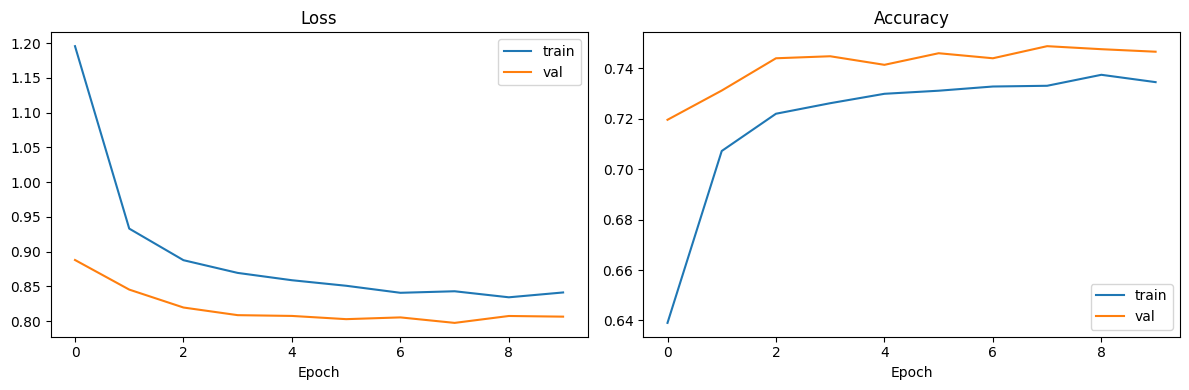

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history["accuracy"], label="train")
axes[1].plot(history["val_accuracy"], label="val")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig(run_dir / "training_curves.png", dpi=150)
plt.show()

### Plot Training Curves (Loss and Accuracy)

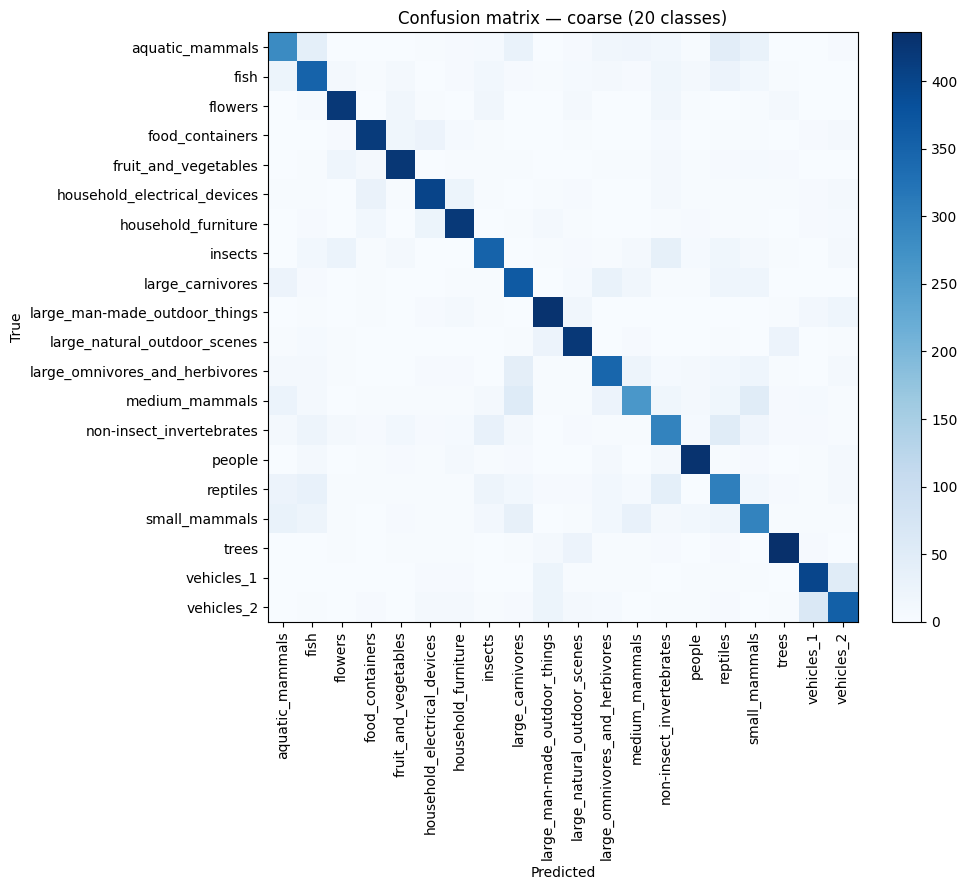

In [16]:
import numpy as np

COARSE_LABELS = [
    "aquatic_mammals", "fish", "flowers", "food_containers",
    "fruit_and_vegetables", "household_electrical_devices",
    "household_furniture", "insects", "large_carnivores",
    "large_man-made_outdoor_things", "large_natural_outdoor_scenes",
    "large_omnivores_and_herbivores", "medium_mammals",
    "non-insect_invertebrates", "people", "reptiles", "small_mammals",
    "trees", "vehicles_1", "vehicles_2",
]

cm = np.array(metrics["confusion_matrix"])

fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(20)); ax.set_xticklabels(COARSE_LABELS, rotation=90)
ax.set_yticks(range(20)); ax.set_yticklabels(COARSE_LABELS)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Confusion matrix — coarse (20 classes)")
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.savefig(run_dir / "confusion_matrix.png", dpi=150)
plt.show()

### Plot Confusion Matrix for Coarse Classes

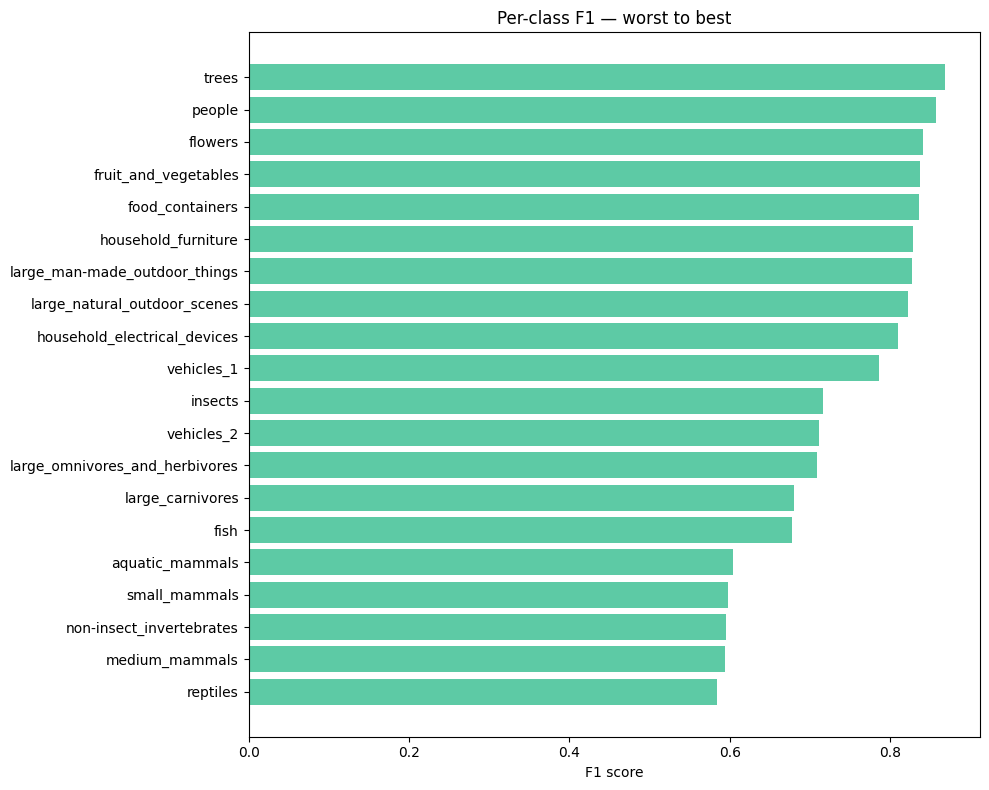

In [17]:
diag = np.diag(cm)
col_sums = cm.sum(axis=0)
row_sums = cm.sum(axis=1)

precision = np.divide(diag, col_sums, out=np.zeros_like(diag, dtype=float), where=col_sums != 0)
recall = np.divide(diag, row_sums, out=np.zeros_like(diag, dtype=float), where=row_sums != 0)
f1 = np.divide(2 * precision * recall, precision + recall,
                out=np.zeros_like(diag, dtype=float), where=(precision + recall) != 0)

order = np.argsort(f1)  # worst classes first

fig, ax = plt.subplots(figsize=(10, 8))
y = np.arange(20)
ax.barh(y, f1[order], color="#5DCAA5")
ax.set_yticks(y)
ax.set_yticklabels([COARSE_LABELS[i] for i in order])
ax.set_xlabel("F1 score")
ax.set_title("Per-class F1 — worst to best")
plt.tight_layout()
plt.savefig(run_dir / "per_class_f1.png", dpi=150)
plt.show()

### Load CIFAR-100 Test Data

### Plot Per-Class F1 Score

157/157 ━━━━━━━━━━━━━━━━━━━━ 17s 61ms/step


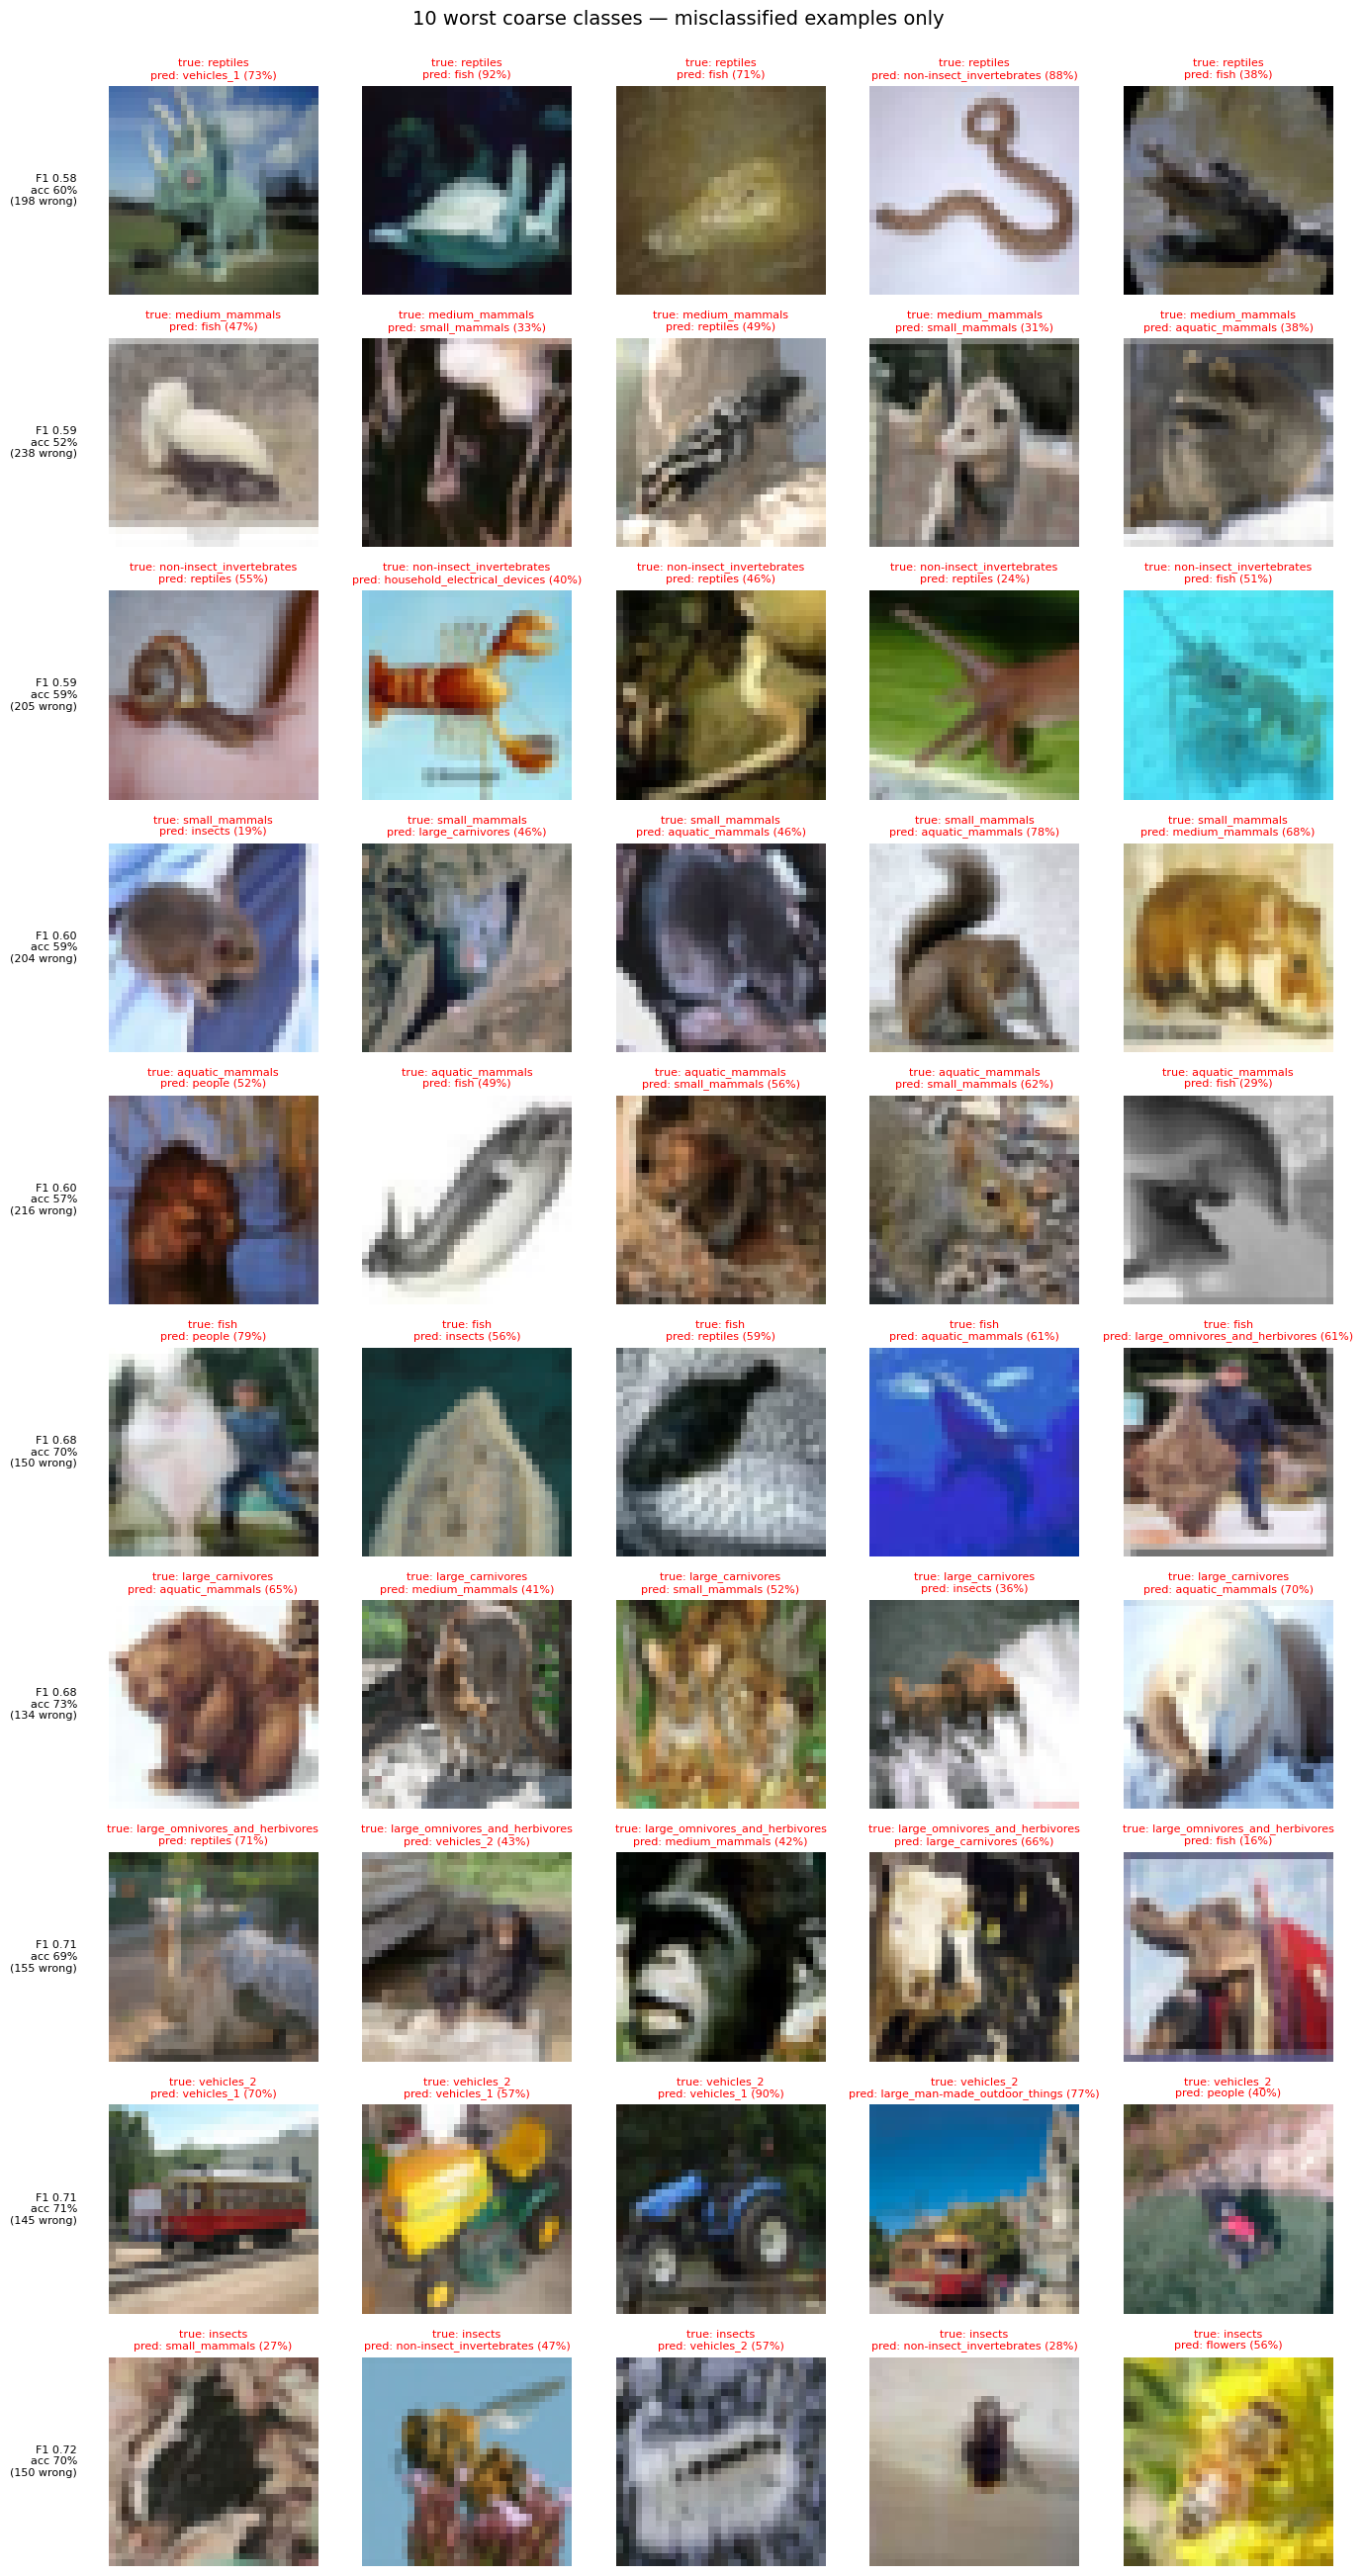

In [19]:
# Worst-10 misclassified examples grid with ground-truth and predicted labels.
test_labels = test_coarse
worst10 = order[:10]

model = build_efficientnet_b0(
    num_classes=20,
    dropout=0.3,
    freeze_backbone=True,
    input_size=96,
)
model.load_weights(run_dir / "model.weights.h5") # Corrected this line

test_images_normalized = test_images.astype(np.float32) / 255.0
probs = model.predict(test_images_normalized, batch_size=64, verbose=1)
preds = probs.argmax(axis=1)
confidences = probs.max(axis=1)

fig, axes = plt.subplots(10, 5, figsize=(14, 26))

for row, cat_id in enumerate(worst10):
    category = COARSE_LABELS[cat_id]
    is_this_class = test_labels == cat_id
    wrong_idx = np.flatnonzero(is_this_class & (preds != cat_id))

    acc = (preds[is_this_class] == cat_id).mean()
    n_wrong = len(wrong_idx)

    shown = wrong_idx[:5]
    for col in range(5):
        ax = axes[row, col]
        if col < len(shown):
            idx = shown[col]
            ax.imshow(test_images[idx])
            ax.set_title(
                f"true: {category}\npred: {COARSE_LABELS[preds[idx]]} ({confidences[idx]:.0%})",
                fontsize=8,
                color="red",
            )
        ax.axis("off")
        if col == 0:
            ax.text(
                -0.15,
                0.5,
                f"F1 {f1[cat_id]:.2f}\nacc {acc:.0%}\n({n_wrong} wrong)",
                transform=ax.transAxes,
                fontsize=8,
                va="center",
                ha="right",
            )

fig.suptitle("10 worst coarse classes — misclassified examples only", fontsize=14, y=1.0)
plt.tight_layout()
plt.savefig(run_dir / "worst10_misclassified.png", dpi=150)
plt.show()